In [ ]:
Dimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
# Mount Google Drive
if os.path.exists("/content/drive"):
    try:
        !fusermount -u /content/drive 2>/dev/null
        !rm -rf /content/drive
    except Exception as e:
        print("Unmount warning:", e)

from google.colab import drive
drive.mount('/content/drive')

data_dir = Path('/content/drive/MyDrive/nba-draft-sucess/final_master')

def hist_plot(series, title):
    plt.figure()
    series.dropna().hist(bins=40)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel('Count')
    plt.show()

def box_plot(series, title):
    plt.figure()
    plt.boxplot(series.dropna(), vert=True)
    plt.title(title)
    plt.ylabel(series.name)
    plt.show()

def missingness_heatmap(df, title):
    M = df.isna().astype(int).values
    plt.figure(figsize=(10, 4))
    plt.imshow(M, aspect='auto')
    plt.title(title + ' (1=missing)')
    plt.xlabel('Columns')
    plt.ylabel('Rows (sample)')
    plt.colorbar()
    plt.show()

def corr_heatmap(df, title):
    C = df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    im = plt.imshow(C, cmap='coolwarm', interpolation='nearest', aspect='auto')
    plt.title(title)
    plt.xticks(range(len(C.columns)), C.columns, rotation=90)
    plt.yticks(range(len(C.index)), C.index)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    return C


Mounted at /content/drive


In [ ]:
paths = {
    "final": data_dir / "final_training_dataset.csv",
    "labels": data_dir / "nba_stats_with_labels.csv",
    "matched": data_dir / "college_combine_features_matched.csv",
    "new_players": data_dir / "college_combine_new_players.csv",
}

dfs = {k: pd.read_csv(p) for k, p in paths.items()}

for name, df in dfs.items():
    print(f"{name}: shape={df.shape}")
    display(df.head(3))


final: shape=(109, 113)


,join_key,G_per_game,GS_per_game,MP_per_game,FG_college,FGA_college,FG%_college,3P_college,3PA_college,3P%_college,2P_college,2PA_college,2P%_college,eFG%_college,FT_college,FTA_college,FT%_college,ORB_college,DRB_college,TRB_college,AST_college,STL_college,BLK_college,TOV_college,PF_college,PTS_college,PER_college,TS%_college,3PAr_college,FTr_college,PProd,ORB%_college,DRB%_college,TRB%_college,AST%_college,STL%_college,BLK%_college,TOV%_college,USG%_college,OWS_college,DWS_college,WS_college,WS/40,OBPM_college,DBPM_college,BPM_college,POS_college,HGT,WGT,BMI,BF,WNGSPN,STNDRCH,HANDL,HANDW,STNDVERT,LPVERT,LANE,SHUTTLE,SPRINT,BENCH,BAR,PAN,PBHGT,PDHGT,Player,POS_nba,PER_nba,TS%_nba,3PAr_nba,FTr_nba,ORB%_nba,DRB%_nba,TRB%_nba,AST%_nba,STL%_nba,BLK%_nba,TOV%_nba,USG%_nba,OWS_nba,DWS_nba,WS_nba,WS/48,OBPM_nba,DBPM_nba,BPM_nba,VORP,GP,GS,MP,FG_nba,FGA_nba,FG%_nba,3P_nba,3PA_nba,3P%_nba,2P_nba,2PA_nba,2P%_nba,eFG%_nba,FT_nba,FTA_nba,FT%_nba,ORB_nba,DRB_nba,TRB_nba,AST_nba,STL_nba,BLK_nba,TOV_nba,PF_nba,PTS_nba,Label
0,aaron gordon,38.0,38.0,31.2,5.0,10.1,0.50,0.4,1.2,0.36,4.60,8.90,0.51,0.52,2.0,4.70,0.42,2.70,5.3,8.0,2.0,0.9,1.0,1.40,2.4,12.40,20.40,0.50,0.12,0.47,469.0,10.4,19.30,14.90,13.0,1.8,3.4,10.50,23.2,2.10,3.3,5.40,0.18,3.7,4.7,8.4,NaN,79.5,220.1,24.5,0.05,83.75,105.0,8.75,10.5,32.5,39.0,10.81,2.76,3.27,NaN,NaN,91.9,137.5,144.0,Aaron Gordon,PF,15.52,0.56,0.30,0.31,6.53,16.76,11.62,13.95,1.22,1.91,11.68,19.95,2.07,1.70,3.77,0.10,0.50,-0.31,0.19,1.02,59,52,28.74,4.99,10.38,0.48,1.10,3.24,0.33,3.90,7.15,0.55,0.53,2.16,3.16,0.69,1.70,4.37,6.08,2.75,0.71,0.63,1.54,1.92,13.25,Starter
1,alec burks,38.0,37.0,31.4,6.6,14.1,0.47,0.7,2.5,0.29,5.90,11.60,0.51,0.50,6.6,7.90,0.82,2.40,4.1,6.5,2.9,1.1,0.3,2.60,2.3,20.50,29.40,0.57,0.18,0.56,771.0,9.2,14.80,12.10,19.6,2.0,1.0,12.70,32.3,5.60,1.0,6.60,0.22,8.0,0.0,8.1,NaN,77.0,192.6,22.8,0.05,82.00,103.5,9.00,8.3,29.0,36.0,10.96,NaN,3.17,5.0,NaN,74.3,132.5,139.5,Alec Burks,SG,13.56,0.54,0.39,0.32,2.61,14.13,8.31,12.92,1.50,0.77,10.31,21.59,1.01,0.82,1.83,0.08,-0.37,-0.54,-0.91,0.38,47,10,21.49,3.42,8.33,0.41,1.25,3.27,0.36,2.16,5.06,0.43,0.48,2.28,2.78,0.81,0.51,2.71,3.22,1.86,0.62,0.20,1.07,1.60,10.36,Role Player
2,alex len,30.0,24.0,23.8,3.5,6.4,0.54,0.0,0.1,0.06,3.45,6.25,0.55,0.54,2.0,3.05,0.64,2.25,4.4,6.6,0.8,0.2,2.1,1.55,2.6,8.95,20.75,0.57,0.02,0.48,282.5,11.0,21.35,16.15,6.9,0.5,9.0,17.65,19.5,1.75,1.3,3.05,0.15,1.5,3.2,4.7,NaN,NaN,NaN,NaN,0.06,87.50,NaN,9.00,10.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.8,NaN,NaN,Alex Len,C,13.67,0.57,0.12,0.39,10.71,21.59,16.07,8.12,0.98,4.92,19.07,15.43,0.81,0.83,1.66,0.09,-2.71,0.44,-2.24,0.07,48,17,14.82,2.16,4.09,0.53,0.15,0.48,0.28,2.00,3.63,0.56,0.55,1.03,1.57,0.61,1.45,2.98,4.45,0.79,0.30,0.80,0.95,2.08,5.49,Role Player


labels: shape=(332, 48)


,Player,POS,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,GP,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Label
0,J.R. Giddens,SG,0.38,0.21,7.73,8.68,7.55,4.18,0.92,0.06,12.54,12.61,-0.18,0.09,0.08,-0.11,-6.66,-2.60,-9.25,-0.02,NaN,NaN,2,0,3.90,0.31,0.91,0.23,0.04,0.22,0.30,0.7,0.21,0.26,0.03,0.04,0.24,0.36,0.58,0.15,0.13,0.04,0.27,0.44,0.84,23.71,21.00,Bust
1,Aaron Brooks,PG,12.17,0.51,0.42,0.18,2.36,6.44,4.41,23.29,1.41,0.82,15.34,22.01,0.82,0.62,1.46,0.05,-0.69,-1.24,-1.92,0.18,52,14,19.26,3.11,7.69,0.40,1.11,3.15,0.35,2.0,4.52,0.44,0.48,1.29,1.50,0.83,0.38,1.14,1.51,2.87,0.54,0.14,1.45,1.78,8.64,Bust
2,Aaron Gordon,PF,15.52,0.56,0.30,0.31,6.53,16.76,11.62,13.95,1.22,1.91,11.68,19.95,2.07,1.70,3.77,0.10,0.50,-0.31,0.19,1.02,59,52,28.74,4.99,10.38,0.48,1.10,3.24,0.33,3.9,7.15,0.55,0.53,2.16,3.16,0.69,1.70,4.37,6.08,2.75,0.71,0.63,1.54,1.92,13.25,Starter


matched: shape=(109, 65)


,join_key,G_per_game,GS_per_game,MP_per_game,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,PER,TS%,3PAr,FTr,PProd,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/40,OBPM,DBPM,BPM,POS,HGT,WGT,BMI,BF,WNGSPN,STNDRCH,HANDL,HANDW,STNDVERT,LPVERT,LANE,SHUTTLE,SPRINT,BENCH,BAR,PAN,PBHGT,PDHGT
0,aaron gordon,38.0,38.0,31.2,5.0,10.1,0.50,0.4,1.2,0.36,4.60,8.90,0.51,0.52,2.0,4.70,0.42,2.70,5.3,8.0,2.0,0.9,1.0,1.40,2.4,12.40,20.40,0.50,0.12,0.47,469.0,10.4,19.30,14.90,13.0,1.8,3.4,10.50,23.2,2.10,3.3,5.40,0.18,3.7,4.7,8.4,NaN,79.5,220.1,24.5,0.05,83.75,105.0,8.75,10.5,32.5,39.0,10.81,2.76,3.27,NaN,NaN,91.9,137.5,144.0
1,alec burks,38.0,37.0,31.4,6.6,14.1,0.47,0.7,2.5,0.29,5.90,11.60,0.51,0.50,6.6,7.90,0.82,2.40,4.1,6.5,2.9,1.1,0.3,2.60,2.3,20.50,29.40,0.57,0.18,0.56,771.0,9.2,14.80,12.10,19.6,2.0,1.0,12.70,32.3,5.60,1.0,6.60,0.22,8.0,0.0,8.1,NaN,77.0,192.6,22.8,0.05,82.00,103.5,9.00,8.3,29.0,36.0,10.96,NaN,3.17,5.0,NaN,74.3,132.5,139.5
2,alex len,30.0,24.0,23.8,3.5,6.4,0.54,0.0,0.1,0.06,3.45,6.25,0.55,0.54,2.0,3.05,0.64,2.25,4.4,6.6,0.8,0.2,2.1,1.55,2.6,8.95,20.75,0.57,0.02,0.48,282.5,11.0,21.35,16.15,6.9,0.5,9.0,17.65,19.5,1.75,1.3,3.05,0.15,1.5,3.2,4.7,NaN,NaN,NaN,NaN,0.06,87.50,NaN,9.00,10.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.8,NaN,NaN


new_players: shape=(408, 65)


,join_key,G_per_game,GS_per_game,MP_per_game,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,PER,TS%,3PAr,FTr,PProd,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/40,OBPM,DBPM,BPM,POS,HGT,WGT,BMI,BF,WNGSPN,STNDRCH,HANDL,HANDW,STNDVERT,LPVERT,LANE,SHUTTLE,SPRINT,BENCH,BAR,PAN,PBHGT,PDHGT
0,aaron harrison,39.50,39.00,29.15,4.05,9.90,0.41,1.55,4.60,0.34,2.50,5.30,0.47,0.49,2.75,3.5,0.79,0.50,2.25,2.80,1.65,1.10,0.25,1.25,1.85,12.35,17.50,0.53,0.46,0.35,443.50,2.1,8.50,5.5,11.35,2.35,0.75,9.65,22.50,2.90,2.15,5.15,0.18,3.70,3.85,7.60,NaN,76.50,209.2,25.1,0.06,80.25,100.5,8.75,10.0,28.5,34.5,NaN,NaN,3.27,1.0,NaN,87.5,129.0,135.0
1,aaron henry,32.33,25.67,27.90,3.97,8.77,0.46,0.77,2.30,0.34,3.23,6.47,0.50,0.51,1.77,2.4,0.72,1.13,3.53,4.67,2.70,0.90,0.80,2.07,1.90,10.50,16.17,0.54,0.26,0.27,322.67,4.9,13.23,9.3,18.47,1.93,2.83,17.63,20.83,1.27,1.43,2.73,0.12,3.03,3.73,6.73,NaN,76.50,209.6,25.2,0.06,82.75,103.5,8.50,9.3,29.0,35.0,11.68,3.18,3.07,NaN,NaN,78.6,132.5,138.5
2,aaron holiday,33.67,21.67,31.93,4.73,10.50,0.45,1.80,4.23,0.42,2.93,6.27,0.47,0.53,3.07,3.9,0.78,0.47,2.70,3.20,4.73,1.27,0.23,3.03,2.70,14.30,17.10,0.57,0.40,0.36,499.67,1.7,8.67,5.4,25.10,2.20,0.70,19.90,23.03,2.23,1.07,3.30,0.12,2.80,1.30,4.07,NaN,71.75,187.0,25.5,0.06,79.50,97.0,8.75,8.5,25.5,33.0,10.96,3.22,3.27,NaN,NaN,74.4,122.5,130.0



=== FINAL INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Columns: 113 entries, join_key to Label
dtypes: float64(107), int64(2), object(4)
memory usage: 96.4+ KB
None

Top missing columns:
POS_college    1.000000
BAR            1.000000
SHUTTLE        0.541284
BENCH          0.385321
LANE           0.256881
SPRINT         0.238532
LPVERT         0.229358
STNDVERT       0.229358
PBHGT          0.229358
PDHGT          0.229358
3P%_college    0.018349
HANDL          0.018349
HANDW          0.018349
PAN            0.018349
HGT            0.009174
dtype: float64


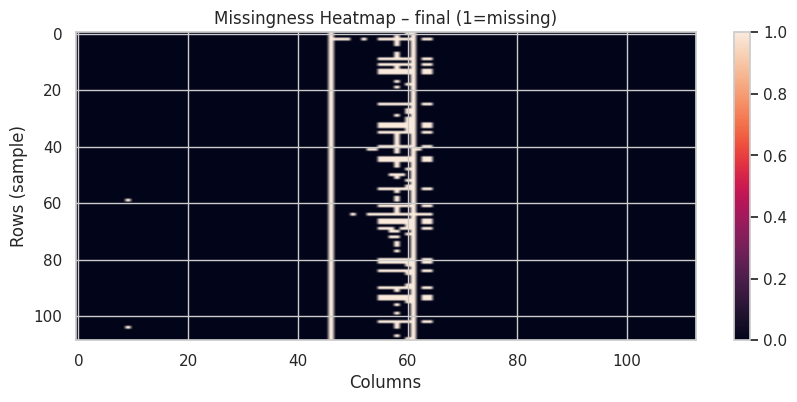


=== LABELS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  332 non-null    object 
 1   POS     331 non-null    object 
 2   PER     332 non-null    float64
 3   TS%     332 non-null    float64
 4   3PAr    332 non-null    float64
 5   FTr     332 non-null    float64
 6   ORB%    332 non-null    float64
 7   DRB%    332 non-null    float64
 8   TRB%    332 non-null    float64
 9   AST%    332 non-null    float64
 10  STL%    332 non-null    float64
 11  BLK%    332 non-null    float64
 12  TOV%    332 non-null    float64
 13  USG%    332 non-null    float64
 14  OWS     332 non-null    float64
 15  DWS     332 non-null    float64
 16  WS      332 non-null    float64
 17  WS/48   332 non-null    float64
 18  OBPM    332 non-null    float64
 19  DBPM    332 non-null    float64
 20  BPM     331 non-null    float64
 21  VORP    331 non-nu

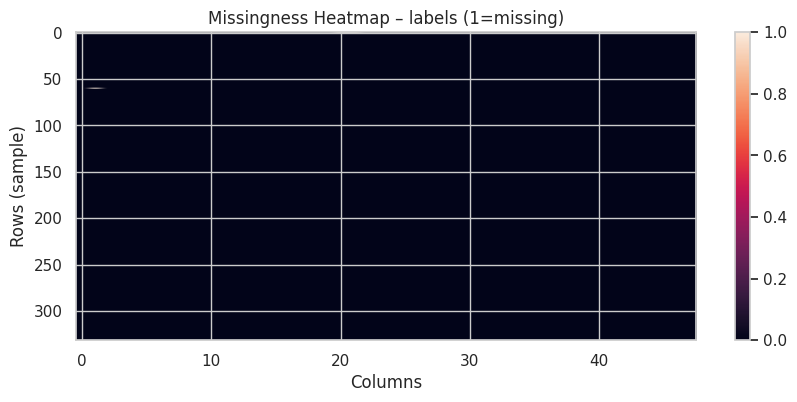


=== MATCHED INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 65 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   join_key     109 non-null    object 
 1   G_per_game   109 non-null    float64
 2   GS_per_game  109 non-null    float64
 3   MP_per_game  109 non-null    float64
 4   FG           109 non-null    float64
 5   FGA          109 non-null    float64
 6   FG%          109 non-null    float64
 7   3P           109 non-null    float64
 8   3PA          109 non-null    float64
 9   3P%          107 non-null    float64
 10  2P           109 non-null    float64
 11  2PA          109 non-null    float64
 12  2P%          109 non-null    float64
 13  eFG%         109 non-null    float64
 14  FT           109 non-null    float64
 15  FTA          109 non-null    float64
 16  FT%          109 non-null    float64
 17  ORB          109 non-null    float64
 18  DRB          109 non-null   

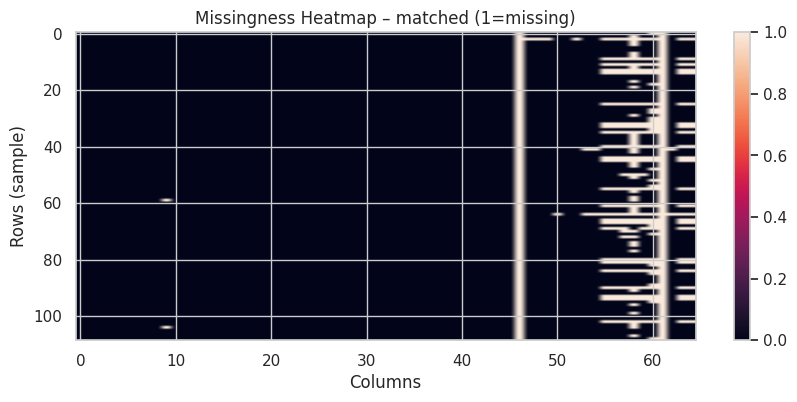


=== NEW_PLAYERS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 65 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   join_key     408 non-null    object 
 1   G_per_game   408 non-null    float64
 2   GS_per_game  408 non-null    float64
 3   MP_per_game  408 non-null    float64
 4   FG           408 non-null    float64
 5   FGA          408 non-null    float64
 6   FG%          408 non-null    float64
 7   3P           408 non-null    float64
 8   3PA          408 non-null    float64
 9   3P%          406 non-null    float64
 10  2P           408 non-null    float64
 11  2PA          408 non-null    float64
 12  2P%          408 non-null    float64
 13  eFG%         408 non-null    float64
 14  FT           408 non-null    float64
 15  FTA          408 non-null    float64
 16  FT%          408 non-null    float64
 17  ORB          408 non-null    float64
 18  DRB          408 non-nul

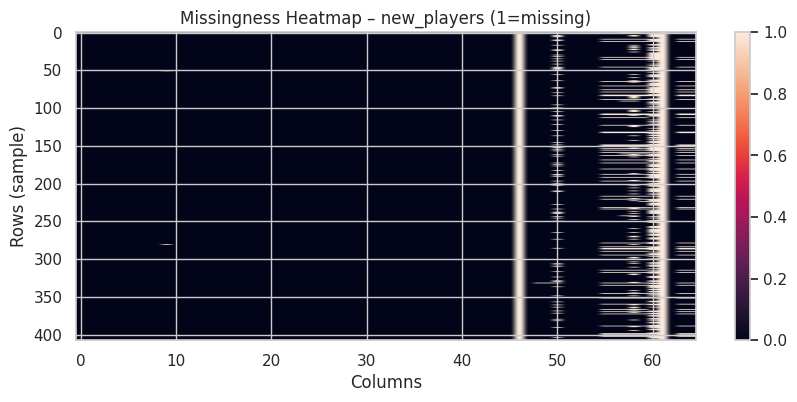

In [ ]:
for name, df in dfs.items():
    print(f"\n=== {name.upper()} INFO ===")
    print(df.info())
    print("\nTop missing columns:")
    miss = df.isna().mean().sort_values(ascending=False)
    print(miss.head(15))
    missingness_heatmap(df, f"Missingness Heatmap – {name}")


In [ ]:
for name, df in dfs.items():
    desc = df.describe(include=[float, int]).T
    print(f"\n=== {name.upper()} DESCRIBE ===")
    print(desc.head(20))



=== FINAL DESCRIBE ===
              count       mean       std    min    25%    50%    75%    max
G_per_game    109.0  33.740092  4.454284  11.00  32.50  34.50  36.00  41.00
GS_per_game   109.0  28.218807  8.908120   0.00  23.50  31.00  35.00  41.00
MP_per_game   109.0  28.905413  4.622456  10.10  26.50  29.78  32.20  37.60
FG_college    109.0   4.790917  1.146157   1.30   3.93   4.90   5.40   7.93
FGA_college   109.0   9.998807  2.626197   2.80   8.10  10.02  11.60  18.00
FG%_college   109.0   0.482569  0.057484   0.39   0.44   0.47   0.52   0.66
3P_college    109.0   1.013486  0.750518   0.00   0.35   1.03   1.60   2.90
3PA_college   109.0   2.816055  1.951842   0.00   1.10   2.85   4.30   7.20
3P%_college   107.0   0.313738  0.118636   0.00   0.29   0.35   0.38   0.60
2P_college    109.0   3.779083  1.151676   0.70   3.00   3.60   4.60   6.70
2PA_college   109.0   7.186606  2.086659   1.20   5.70   7.00   8.50  12.50
2P%_college   109.0   0.524587  0.053844   0.40   0.49   0.52   


labels – Label counts:
Label
Starter        99
Role Player    99
Bust           67
Star           50
Superstar      17
Name: count, dtype: int64


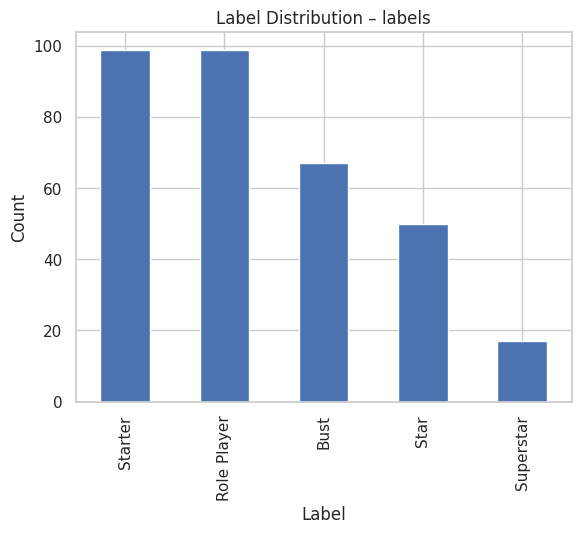


final – Label counts:
Label
Starter        34
Role Player    31
Star           20
Bust           18
Superstar       6
Name: count, dtype: int64


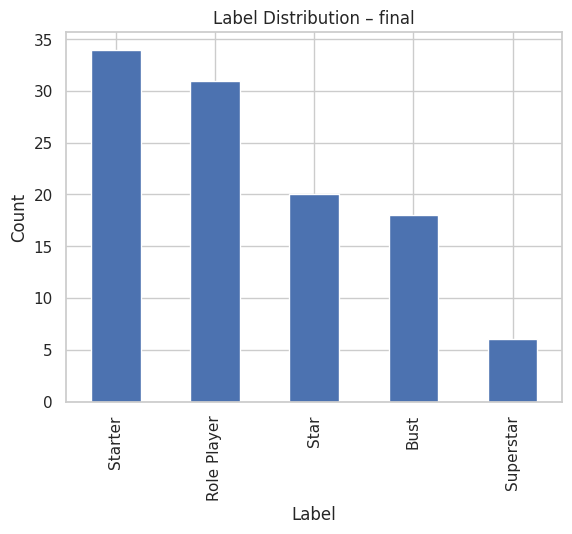

In [ ]:
for name in ["labels", "final"]:
    df = dfs[name]
    label_col = None
    for candidate in ["Label", "label_role", "role_label"]:
        if candidate in df.columns:
            label_col = candidate
            break
    if label_col:
        counts = df[label_col].value_counts(dropna=False)
        print(f"\n{name} – Label counts:")
        print(counts)
        plt.figure()
        counts.plot(kind='bar')
        plt.title(f"Label Distribution – {name}")
        plt.xlabel("Label")
        plt.ylabel("Count")
        plt.show()


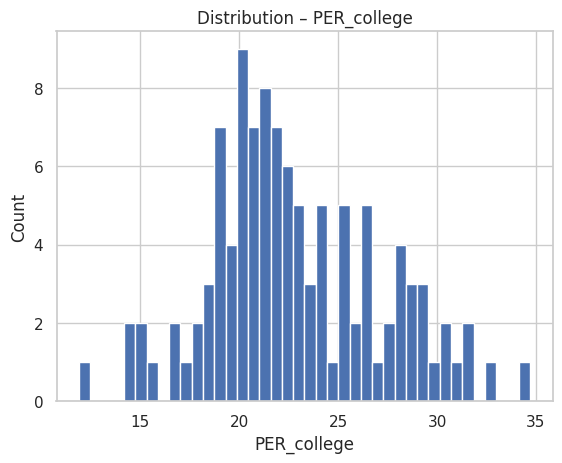

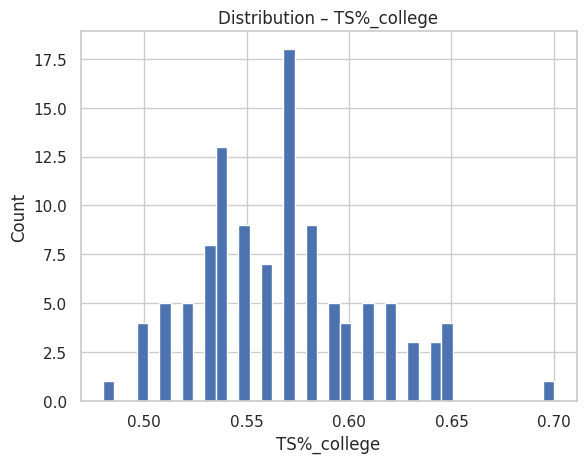

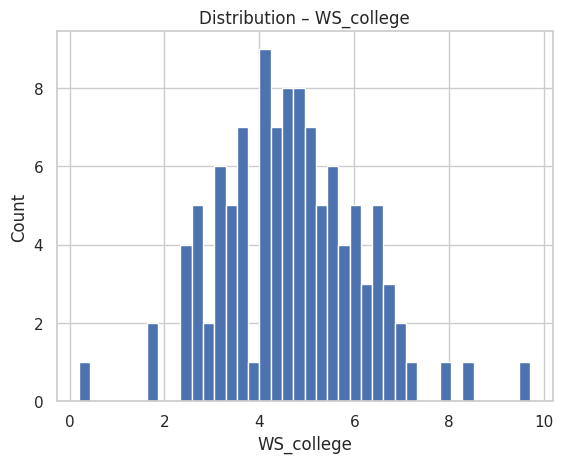

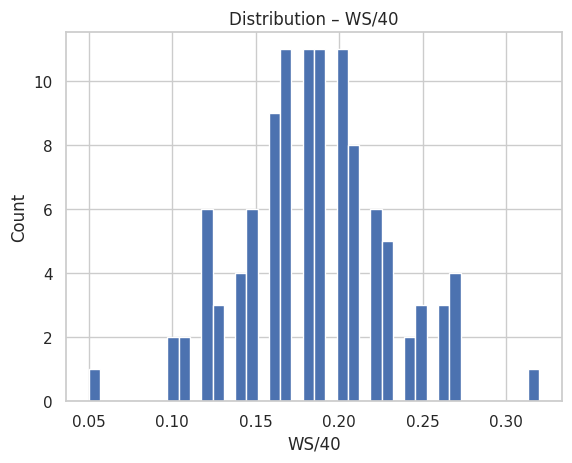

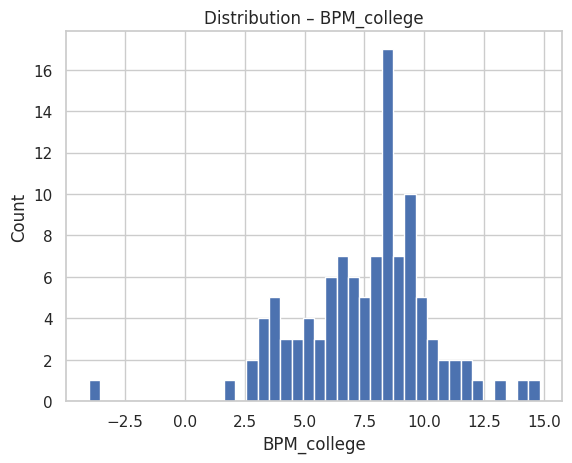

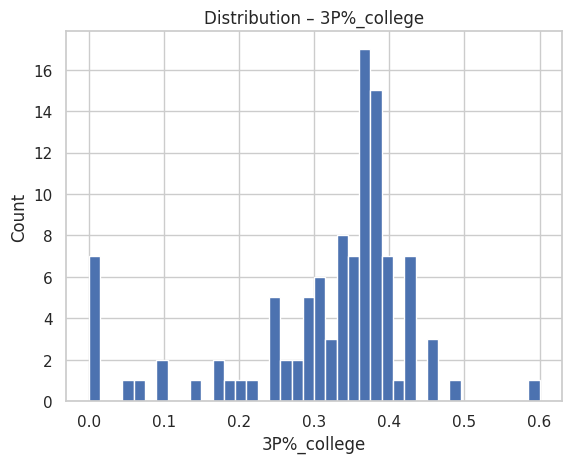

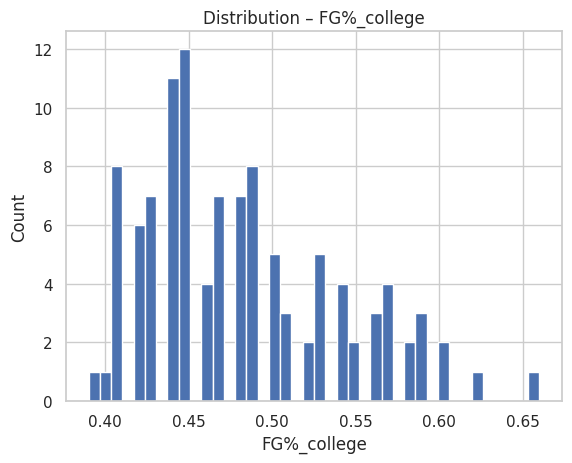

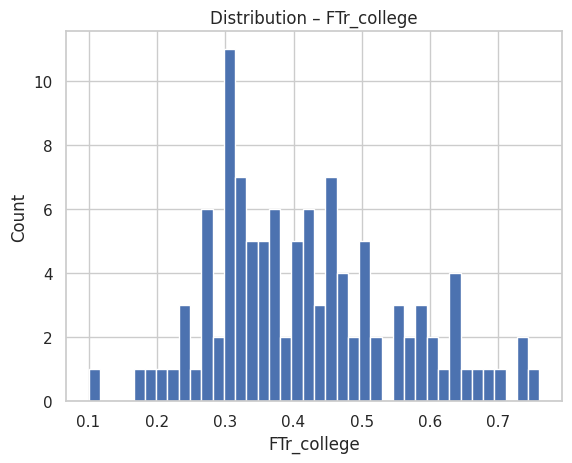

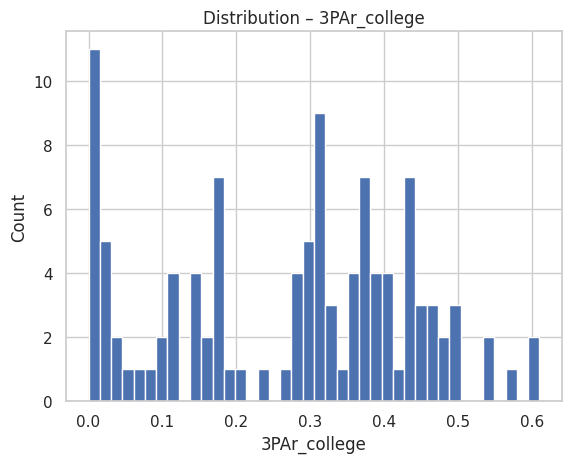

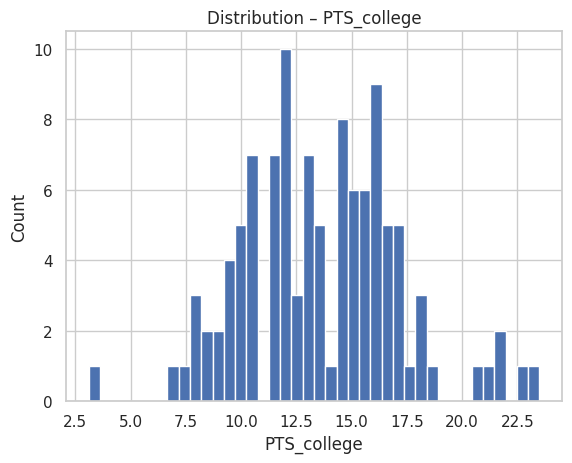

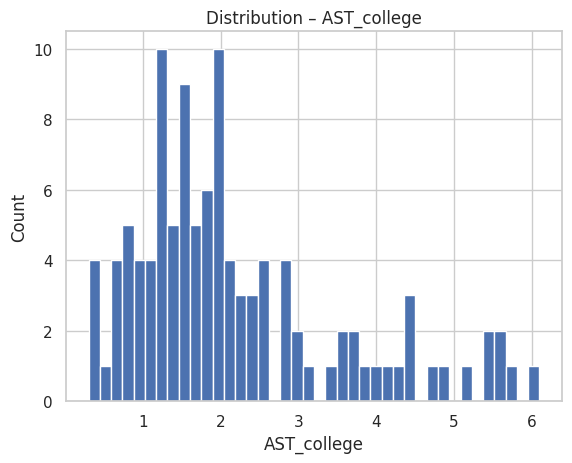

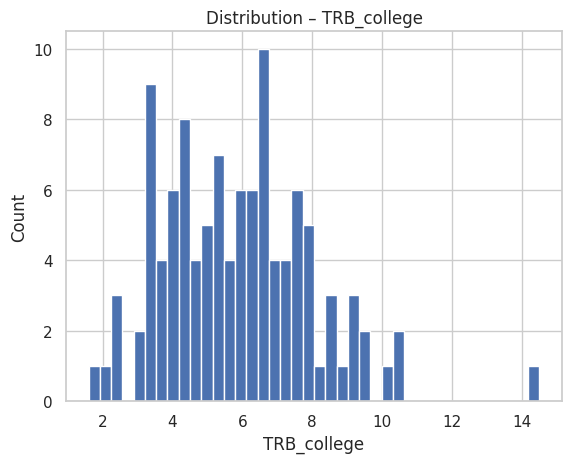

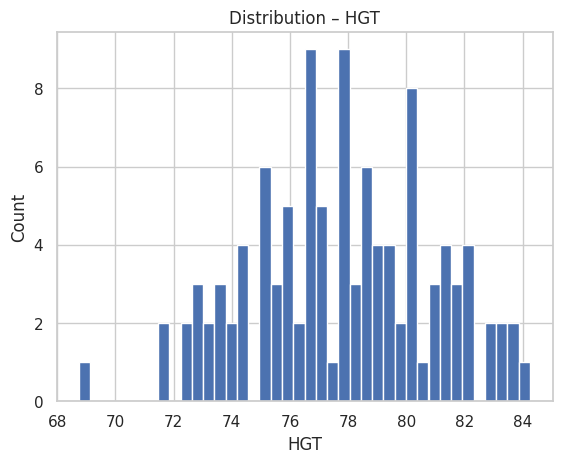

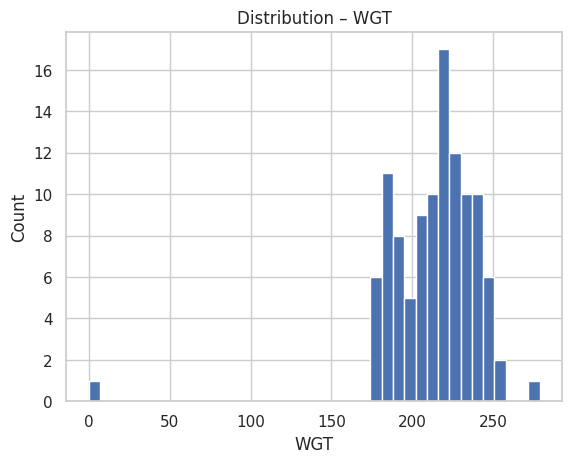

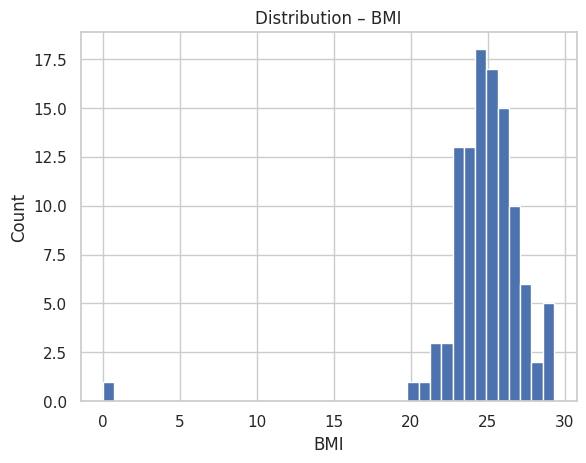

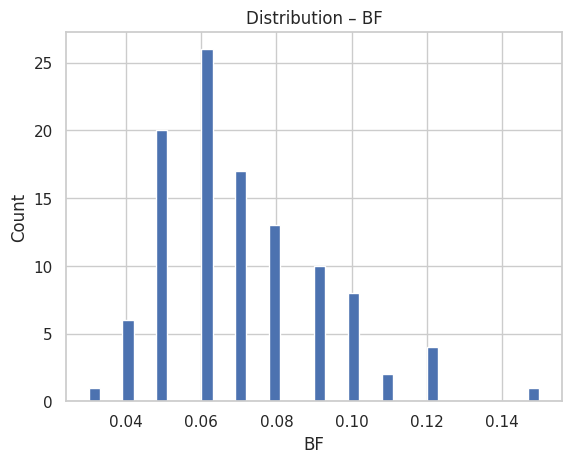

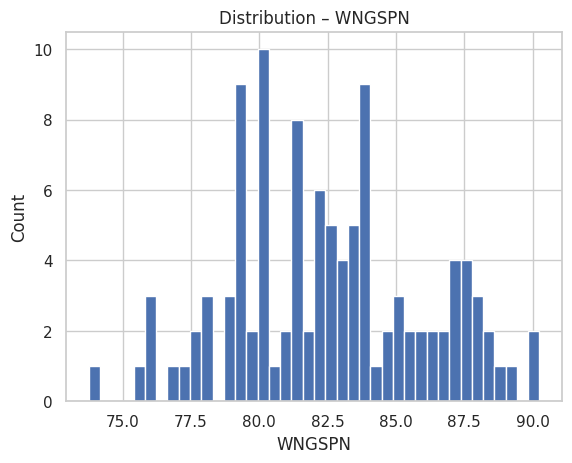

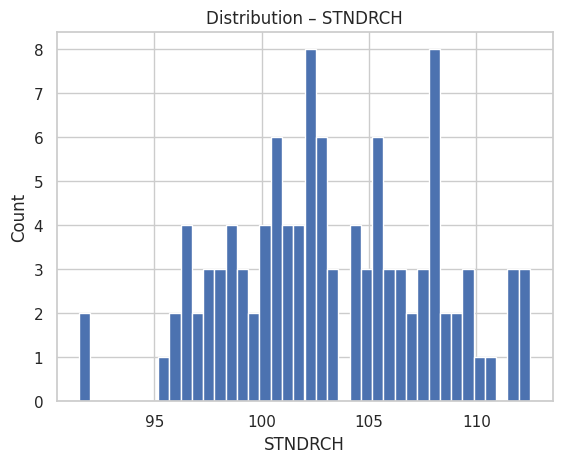

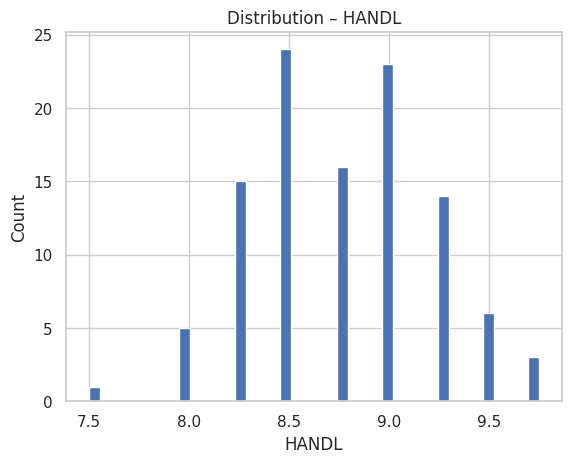

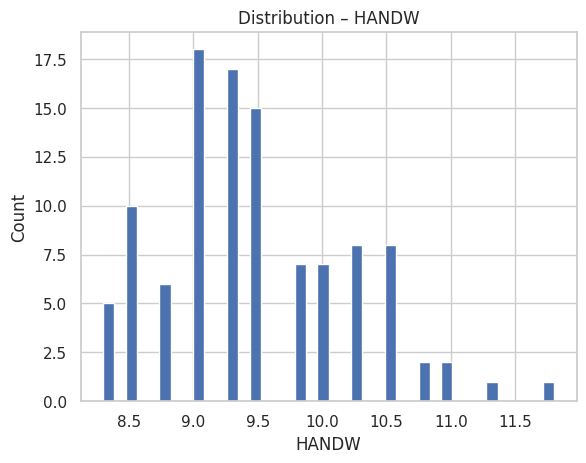

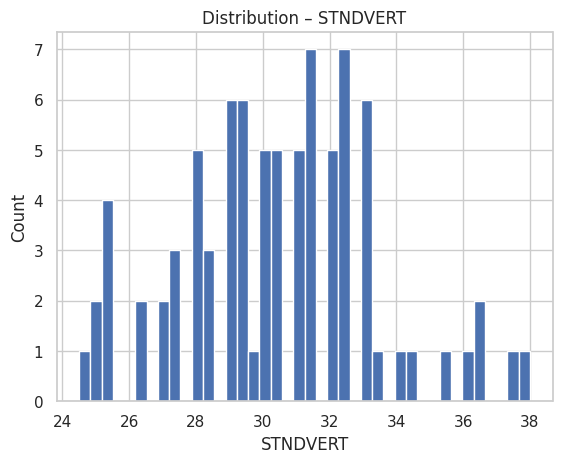

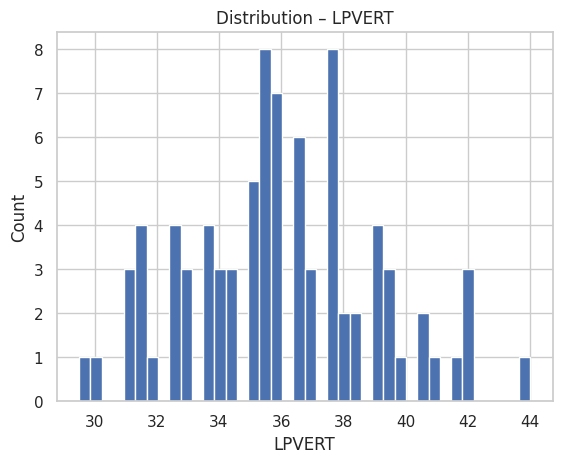

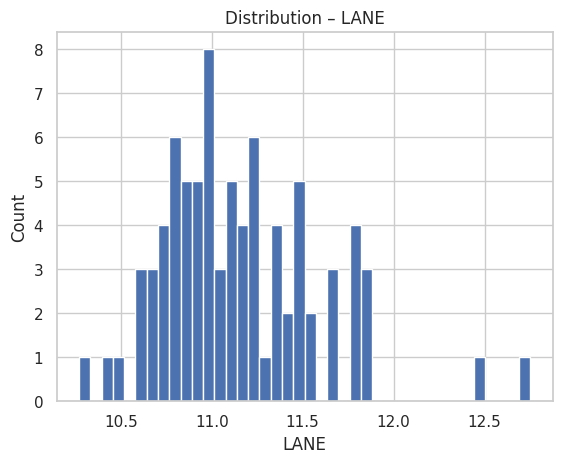

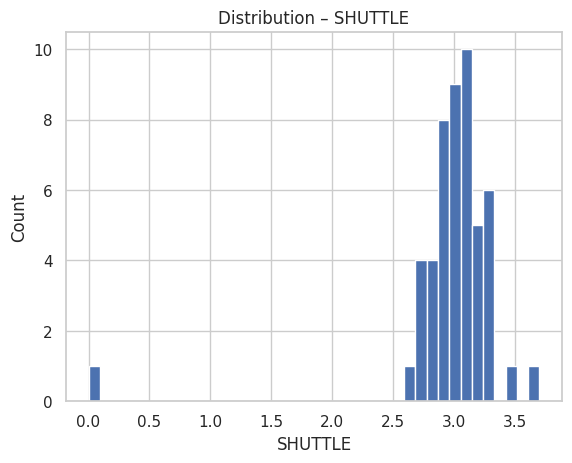

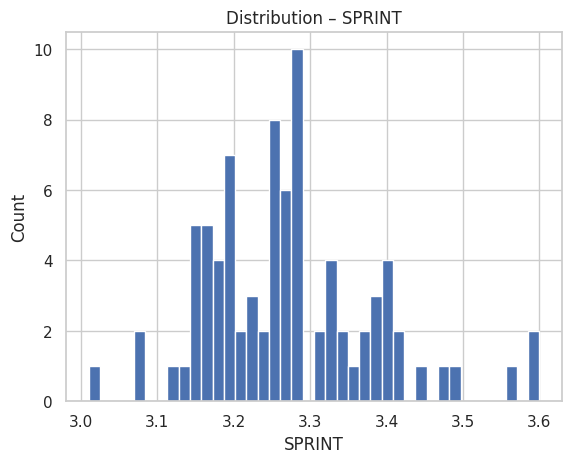

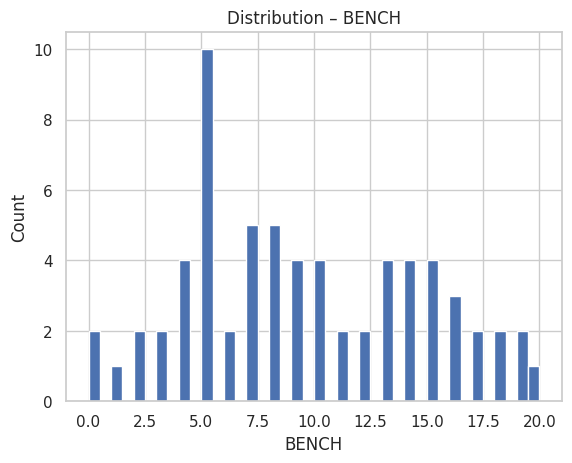

In [ ]:
college_cols = [
    'PER_college','TS%_college','WS_college','WS/40','BPM_college',
    '3P%_college','FG%_college','FTr_college','3PAr_college','PTS_college','AST_college','TRB_college'
]
combine_cols = [
    'HGT','WGT','BMI','BF','WNGSPN','STNDRCH','HANDL','HANDW','STNDVERT','LPVERT','LANE','SHUTTLE','SPRINT','BENCH'
]

final_df = dfs['final']
for col in college_cols + combine_cols:
    if col in final_df.columns:
        hist_plot(final_df[col], f"Distribution – {col}")


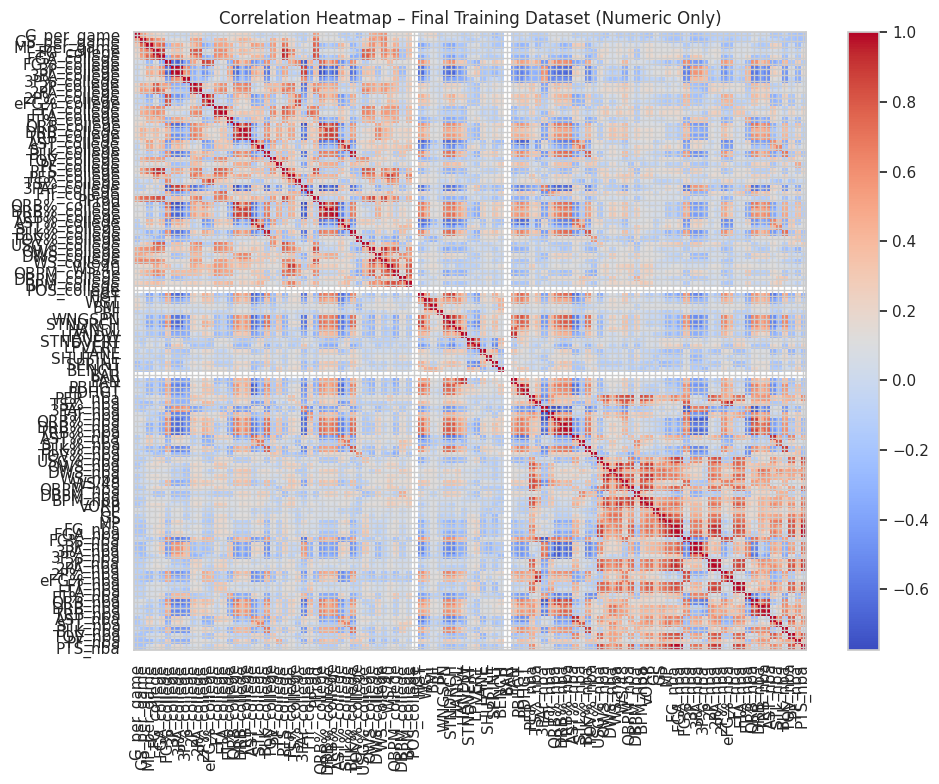


Top correlations with WS_nba:
WS_nba      1.000000
OWS_nba     0.950038
VORP        0.920325
BPM_nba     0.840383
OBPM_nba    0.815588
PER_nba     0.801079
FTA_nba     0.759091
FT_nba      0.758823
WS/48       0.756466
DWS_nba     0.741406
2P_nba      0.725693
GS          0.716190
PTS_nba     0.689328
FG_nba      0.683176
2PA_nba     0.657886
Name: WS_nba, dtype: float64

Top correlations with BPM_nba:
BPM_nba     1.000000
VORP        0.894259
OBPM_nba    0.882286
WS_nba      0.840383
PER_nba     0.828926
OWS_nba     0.802021
WS/48       0.785733
FT_nba      0.669653
FTA_nba     0.654050
PTS_nba     0.634379
2P_nba      0.630887
FG_nba      0.624823
DWS_nba     0.614184
2PA_nba     0.575720
MP          0.554974
Name: BPM_nba, dtype: float64

Top correlations with PER_nba:
PER_nba     1.000000
OBPM_nba    0.844882
WS/48       0.838717
BPM_nba     0.828926
WS_nba      0.801079
OWS_nba     0.799147
2P_nba      0.785182
VORP        0.777858
FTA_nba     0.736578
FT_nba      0.704520
2PA_nb

In [ ]:
final_df = dfs['final']

C = corr_heatmap(final_df.select_dtypes(include=[float, int]),
                 "Correlation Heatmap – Final Training Dataset (Numeric Only)")

targets = ['WS_nba','BPM_nba','PER_nba','VORP']
for t in targets:
    if t in final_df.columns:
        try:
            s = final_df.corr(numeric_only=True)[t]
            print(f"\nTop correlations with {t}:")
            print(s.sort_values(ascending=False).head(15))
        except Exception:
            pass


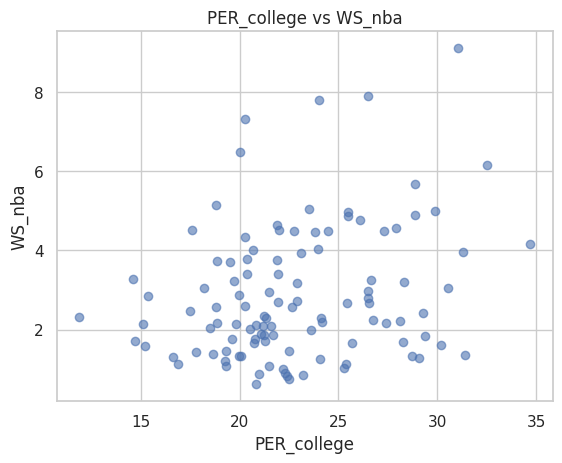

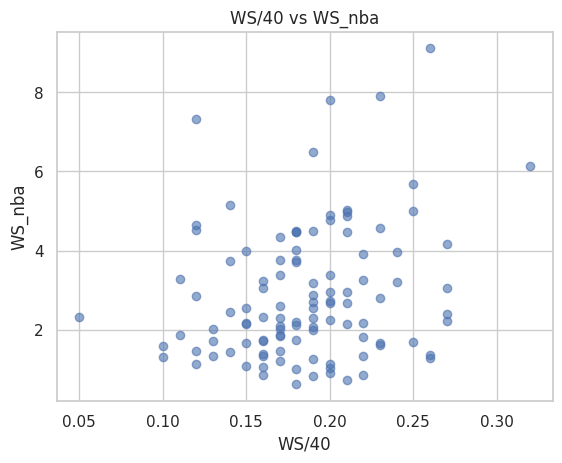

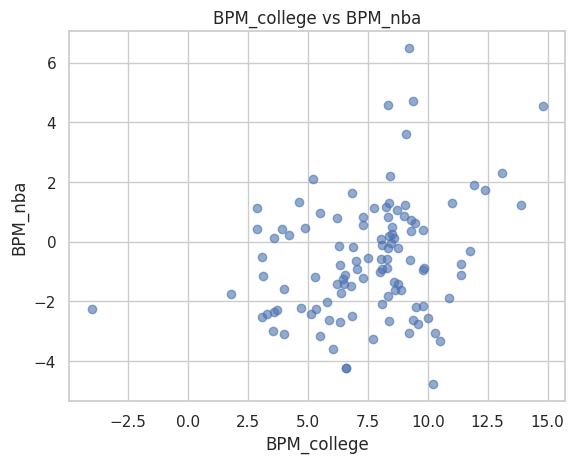

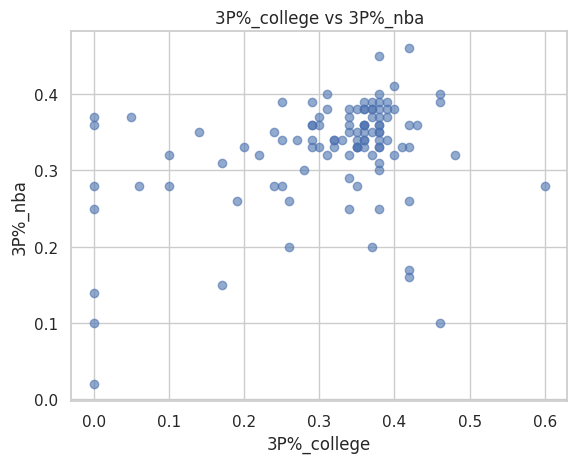

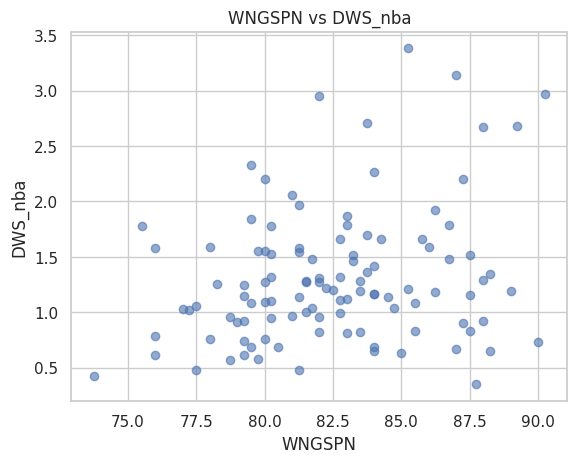

In [ ]:
pairs = [
    ('PER_college','WS_nba'),
    ('WS/40','WS_nba'),
    ('BPM_college','BPM_nba'),
    ('3P%_college','3P%_nba'),
    ('WNGSPN','DWS_nba'),
]

for x, y in pairs:
    if x in final_df.columns and y in final_df.columns:
        plt.figure()
        plt.scatter(final_df[x], final_df[y], alpha=0.6)
        plt.title(f"{x} vs {y}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.show()


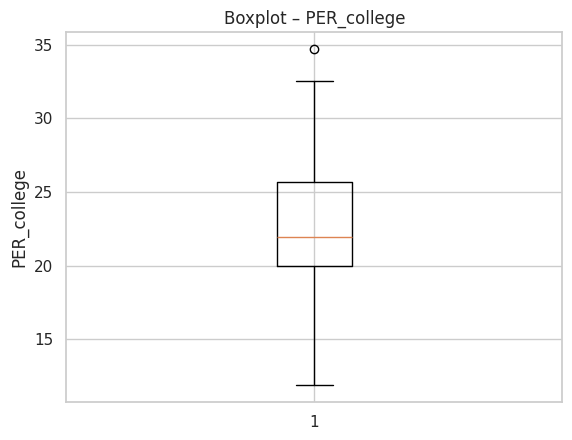

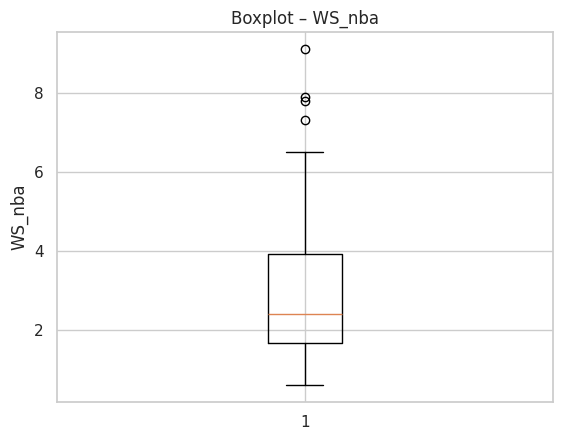

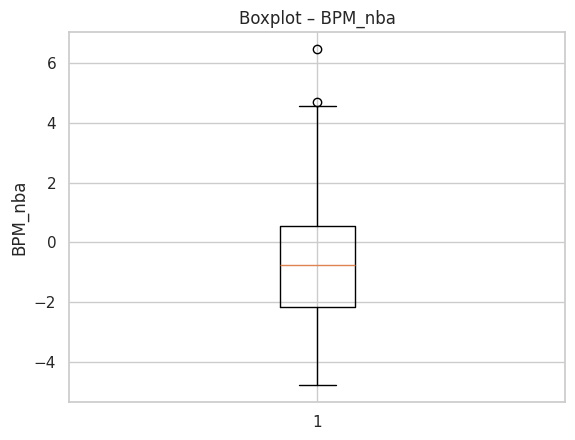

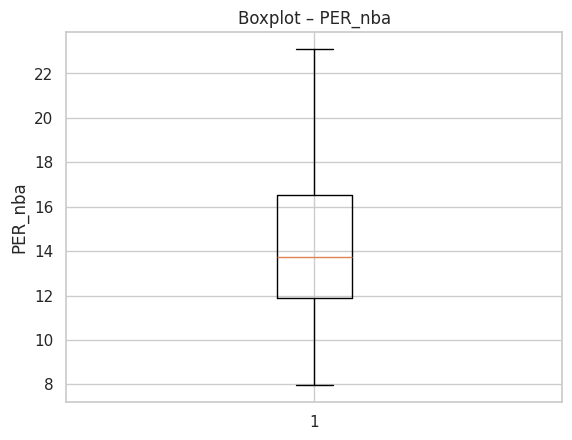

In [ ]:
box_targets = ['PER_college','WS_nba','BPM_nba','PER_nba']
for col in box_targets:
    if col in final_df.columns:
        box_plot(final_df[col], f"Boxplot – {col}")


In [ ]:
summary_stats = final_df.describe(include=[float, int]).T
summary_stats.to_csv((data_dir / 'eda_numeric_summary_final.csv'), index=True)

corr_mat = final_df.corr(numeric_only=True)
corr_mat.to_csv((data_dir / 'eda_correlation_matrix_final.csv'), index=True)

print("Saved: eda_numeric_summary_final.csv and eda_correlation_matrix_final.csv")


Saved: eda_numeric_summary_final.csv and eda_correlation_matrix_final.csv
